# Part 3: Layer-wise Brain Mapping in Transformers (30 Marks)

**Name:** Evan Bijoy  
**Roll Number:** 2023101080

---

Using DINOv2 for hierarchical layer analysis with RSA and CKA.

**Subject:** 02  
**Assigned ROI (d):** Place-selective regions (floc-places) - OPA, PPA, RSC  
**Choice ROI (a):** Early retinotopic regions (prf-visualrois) - V1v, V1d, V2v, V2d, V3v, V3d, hV4

**Model:**
- DINOv2 (ViT-S/14) - Self-supervised vision transformer

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from torchvision import transforms
import json
import warnings
warnings.filterwarnings('ignore')

from utils import (get_paths, load_fmri_data, load_multiple_roi_masks, 
                   get_all_roi_vertices, get_image_paths, train_encoding_model,
                   compute_rdm, compute_rsa, linear_cka, device)

print(f"Using device: {device}")

Using device: cuda


In [2]:
# Configuration
BASE_DIR = r'c:\Users\evanb\OneDrive\Documents\Studies\SEM6\CSAI\A2\neuroai-visual-encoder'
paths = get_paths(BASE_DIR)
N_VERTICES = 10
BATCH_SIZE = 16

In [3]:
# Load data
print("Loading fMRI data...")
fmri_data = load_fmri_data(paths)

print("\nLoading ROI masks for both ROI types...")
roi_types = ['floc-places', 'prf-visualrois']
roi_masks = load_multiple_roi_masks(paths, roi_types)

print("\nSelecting vertices per ROI...")
roi_data = get_all_roi_vertices(roi_masks, fmri_data, N_VERTICES)

if not roi_data:
    raise RuntimeError("No ROI data found! Check ROI masks.")

print("\nLoading image paths...")
train_images = get_image_paths(paths['train_img'])
test_images = get_image_paths(paths['test_img'])

if len(train_images) == 0 or len(test_images) == 0:
    raise RuntimeError(f"No images found! train={len(train_images)}, test={len(test_images)}")

print(f"Training images: {len(train_images)}, Test images: {len(test_images)}")
print(f"\n✓ Data loaded successfully! ROIs: {list(roi_data.keys())}")

Loading fMRI data...


Training fMRI - LH: (9841, 19004), RH: (9841, 20544)
Test fMRI - LH: (159, 19004), RH: (159, 20544)

Loading ROI masks for both ROI types...

floc-places ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

prf-visualrois ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'V1v', 2: 'V1d', 3: 'V2v', 4: 'V2d', 5: 'V3v', 6: 'V3d', 7: 'hV4'}

Selecting vertices per ROI...

OPA: LH has 1494 vertices, RH has 2434 vertices
  Selected 10 LH + 0 RH vertices

PPA: LH has 1272 vertices, RH has 1490 vertices
  Selected 10 LH + 0 RH vertices

RSC: LH has 481 vertices, RH has 683 vertices
  Selected 10 LH + 0 RH vertices

V1v: LH has 599 vertices, RH has 616 vertices
  Selected 10 LH + 0 RH vertices

V1d: LH has 845 vertices, RH has 677 vertices
  Selected 10 LH + 0 RH vertices

V2v: LH has 653 vertices, RH has 883 vertices
  Selected 10 LH + 0 RH vertices

V2d: LH has 620 vertices, RH has 623 vertices
  Selected 10 LH + 0 RH vertices



---
## DINOv2 Layer-wise Feature Extractor

**Model Details:**
- Checkpoint: `dinov2_vits14` (ViT-Small/14)
- Type: Self-supervised (no language supervision)
- Layers: 12 transformer blocks

In [4]:
class DINOv2FeatureExtractor:
    """Extract layer-wise features from DINOv2."""
    
    def __init__(self, model_name='dinov2_vits14'):
        print(f"Loading DINOv2: {model_name}...")
        self.model = torch.hub.load('facebookresearch/dinov2', model_name)
        self.model.eval()
        self.model.to(device)
        
        self.n_layers = len(self.model.blocks)
        print(f"Number of transformer layers: {self.n_layers}")
        
        self.preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.intermediate_outputs = {}
        self._register_hooks()
    
    def _register_hooks(self):
        def get_hook(name):
            def hook(module, input, output):
                self.intermediate_outputs[name] = output.detach()
            return hook
        
        for i, block in enumerate(self.model.blocks):
            block.register_forward_hook(get_hook(f'layer_{i}'))
    
    def extract_layerwise_features(self, image_paths, layers=None, batch_size=16, pooling='mean'):
        """
        Extract features from specified layers.
        
        Args:
            layers: List of layer indices (default: 4 depths - early/mid/late/final)
            pooling: 'mean' (mean over patches) or 'cls' (CLS token)
        """
        if layers is None:
            layers = [0, self.n_layers//3, 2*self.n_layers//3, self.n_layers-1]
        
        layer_features = {f'layer_{l}': [] for l in layers}
        
        with torch.no_grad():
            for i in tqdm(range(0, len(image_paths), batch_size), desc="DINOv2 Layers"):
                batch_paths = image_paths[i:i+batch_size]
                batch_imgs = [self.preprocess(Image.open(p).convert('RGB')) for p in batch_paths]
                batch_tensor = torch.stack(batch_imgs).to(device)
                
                _ = self.model(batch_tensor)
                
                for l in layers:
                    layer_out = self.intermediate_outputs[f'layer_{l}']
                    if pooling == 'mean':
                        pooled = layer_out[:, 1:, :].mean(dim=1)  # Exclude CLS
                    else:
                        pooled = layer_out[:, 0, :]  # CLS token
                    layer_features[f'layer_{l}'].append(pooled.cpu().numpy())
        
        for key in layer_features:
            layer_features[key] = np.vstack(layer_features[key])
        
        return layer_features, layers

In [5]:
# Initialize DINOv2 and extract layer-wise features
print("Initializing DINOv2...")
dino_extractor = DINOv2FeatureExtractor('dinov2_vits14')

print("\nExtracting layer-wise features...")
dino_train_features, layer_indices = dino_extractor.extract_layerwise_features(
    train_images, batch_size=BATCH_SIZE, pooling='mean'
)
dino_test_features, _ = dino_extractor.extract_layerwise_features(
    test_images, batch_size=BATCH_SIZE, pooling='mean'
)

print(f"\nExtracted layers: {layer_indices}")
for layer_name, feats in dino_train_features.items():
    print(f"  {layer_name}: Train {feats.shape}, Test {dino_test_features[layer_name].shape}")

Initializing DINOv2...
Loading DINOv2: dinov2_vits14...


Using cache found in C:\Users\evanb/.cache\torch\hub\facebookresearch_dinov2_main


Number of transformer layers: 12

Extracting layer-wise features...


DINOv2 Layers: 100%|██████████| 10/10 [00:04<00:00,  2.03it/s]


Extracted layers: [0, 4, 8, 11]
  layer_0: Train (9841, 384), Test (159, 384)
  layer_4: Train (9841, 384), Test (159, 384)
  layer_8: Train (9841, 384), Test (159, 384)
  layer_11: Train (9841, 384), Test (159, 384)


---
## Layer-wise Encoding Models

In [6]:
layerwise_results = {}
layer_names = list(dino_train_features.keys())

print("Layer-wise Encoding Results")
print("="*60)

for layer_name in layer_names:
    layerwise_results[layer_name] = {}
    print(f"\n{layer_name}:")
    
    for roi_name, roi_info in roi_data.items():
        correlations, mean_corr, _ = train_encoding_model(
            dino_train_features[layer_name],
            roi_info['train'],
            dino_test_features[layer_name],
            roi_info['test'],
            alpha=1000
        )
        
        layerwise_results[layer_name][roi_name] = {
            'correlations': correlations.tolist(),
            'mean': float(mean_corr)
        }
        print(f"  {roi_name}: r = {mean_corr:.4f}")

Layer-wise Encoding Results

layer_0:
  OPA: r = 0.3105
  PPA: r = 0.4159
  RSC: r = 0.3719
  V1v: r = 0.3608
  V1d: r = 0.3926
  V2v: r = 0.3148
  V2d: r = 0.3167
  V3v: r = 0.2689
  V3d: r = 0.3641
  hV4: r = 0.4482

layer_4:
  OPA: r = 0.4443
  PPA: r = 0.5676
  RSC: r = 0.4806
  V1v: r = 0.3638
  V1d: r = 0.4172
  V2v: r = 0.3845
  V2d: r = 0.3896
  V3v: r = 0.3404
  V3d: r = 0.4257
  hV4: r = 0.5465

layer_8:
  OPA: r = 0.4792
  PPA: r = 0.5897
  RSC: r = 0.5181
  V1v: r = 0.3577
  V1d: r = 0.3812
  V2v: r = 0.3727
  V2d: r = 0.3718
  V3v: r = 0.2794
  V3d: r = 0.3948
  hV4: r = 0.5155

layer_11:
  OPA: r = 0.4724
  PPA: r = 0.5845
  RSC: r = 0.5260
  V1v: r = 0.2754
  V1d: r = 0.3244
  V2v: r = 0.3330
  V2d: r = 0.3509
  V3v: r = 0.2690
  V3d: r = 0.3375
  hV4: r = 0.4640


---
## Representational Similarity Analysis (RSA) and CKA

In [7]:
# Use subset of test images for computational efficiency
N_RSA_SAMPLES = min(200, len(test_images))
np.random.seed(42)
rsa_indices = np.random.choice(len(test_images), N_RSA_SAMPLES, replace=False)

print(f"Computing RSA and CKA using {N_RSA_SAMPLES} test samples...\n")

rsa_results = {layer: {} for layer in layer_names}
cka_results = {layer: {} for layer in layer_names}

for layer_name in layer_names:
    layer_feats = dino_test_features[layer_name][rsa_indices]
    layer_rdm = compute_rdm(layer_feats)
    
    for roi_name, roi_info in roi_data.items():
        roi_feats = roi_info['test'][rsa_indices]
        roi_rdm = compute_rdm(roi_feats)
        
        # RSA (Spearman correlation between RDMs)
        rsa_val = compute_rsa(layer_rdm, roi_rdm)
        rsa_results[layer_name][roi_name] = float(rsa_val)
        
        # Linear CKA
        cka_val = linear_cka(layer_feats, roi_feats)
        cka_results[layer_name][roi_name] = float(cka_val)

# Print results
roi_names = list(roi_data.keys())

print("RSA Results (Spearman correlation between RDMs):")
for layer in layer_names:
    vals = [f"{roi}={rsa_results[layer][roi]:.3f}" for roi in roi_names]
    print(f"  {layer}: {', '.join(vals)}")

print("\nCKA Results (Linear CKA):")
for layer in layer_names:
    vals = [f"{roi}={cka_results[layer][roi]:.3f}" for roi in roi_names]
    print(f"  {layer}: {', '.join(vals)}")

Computing RSA and CKA using 159 test samples...

RSA Results (Spearman correlation between RDMs):
  layer_0: OPA=0.042, PPA=0.034, RSC=0.004, V1v=0.023, V1d=0.025, V2v=0.045, V2d=0.021, V3v=0.018, V3d=0.005, hV4=0.006
  layer_4: OPA=0.065, PPA=0.083, RSC=0.031, V1v=0.043, V1d=0.060, V2v=0.070, V2d=0.023, V3v=0.024, V3d=0.018, hV4=0.025
  layer_8: OPA=0.077, PPA=0.086, RSC=0.064, V1v=0.052, V1d=0.042, V2v=0.051, V2d=0.010, V3v=0.023, V3d=0.018, hV4=0.028
  layer_11: OPA=0.059, PPA=0.072, RSC=0.044, V1v=0.035, V1d=0.020, V2v=0.034, V2d=0.002, V3v=0.012, V3d=0.013, hV4=0.031

CKA Results (Linear CKA):
  layer_0: OPA=0.066, PPA=0.040, RSC=0.039, V1v=0.105, V1d=0.091, V2v=0.110, V2d=0.121, V3v=0.081, V3d=0.100, hV4=0.115
  layer_4: OPA=0.163, PPA=0.199, RSC=0.145, V1v=0.141, V1d=0.121, V2v=0.158, V2d=0.160, V3v=0.149, V3d=0.142, hV4=0.181
  layer_8: OPA=0.228, PPA=0.265, RSC=0.184, V1v=0.130, V1d=0.118, V2v=0.164, V2d=0.156, V3v=0.170, V3d=0.169, hV4=0.202
  layer_11: OPA=0.207, PPA=0.223, 

---
## Visualization

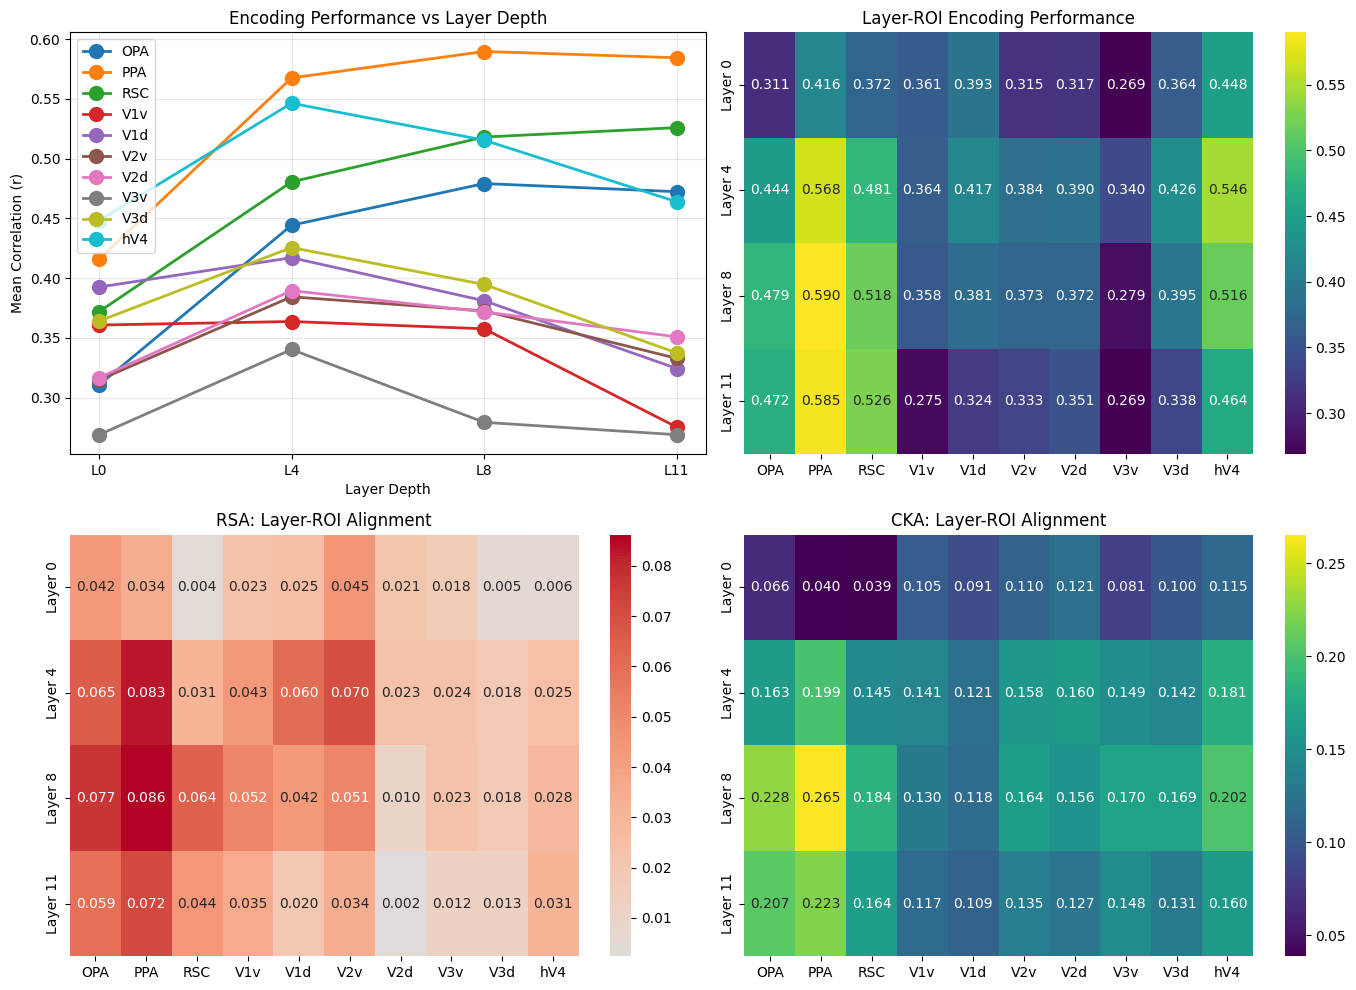

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line plot: encoding performance vs layer depth
ax = axes[0, 0]
for roi_name in roi_names:
    means = [layerwise_results[layer][roi_name]['mean'] for layer in layer_names]
    ax.plot(range(len(layer_names)), means, 'o-', label=roi_name, linewidth=2, markersize=10)

ax.set_xlabel('Layer Depth')
ax.set_ylabel('Mean Correlation (r)')
ax.set_title('Encoding Performance vs Layer Depth')
ax.set_xticks(range(len(layer_names)))
ax.set_xticklabels([f'L{l}' for l in layer_indices])
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Encoding heatmap
ax = axes[0, 1]
enc_matrix = np.array([[layerwise_results[layer][roi]['mean'] 
                        for roi in roi_names] for layer in layer_names])
sns.heatmap(enc_matrix, annot=True, fmt='.3f', 
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='viridis', ax=ax)
ax.set_title('Layer-ROI Encoding Performance')

# 3. RSA heatmap
ax = axes[1, 0]
rsa_matrix = np.array([[rsa_results[layer][roi] for roi in roi_names] for layer in layer_names])
sns.heatmap(rsa_matrix, annot=True, fmt='.3f',
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('RSA: Layer-ROI Alignment')

# 4. CKA heatmap
ax = axes[1, 1]
cka_matrix = np.array([[cka_results[layer][roi] for roi in roi_names] for layer in layer_names])
sns.heatmap(cka_matrix, annot=True, fmt='.3f',
            xticklabels=roi_names, yticklabels=[f'Layer {l}' for l in layer_indices],
            cmap='viridis', ax=ax)
ax.set_title('CKA: Layer-ROI Alignment')

plt.tight_layout()
plt.savefig('part3_layerwise_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Find best layer per ROI
print("Best layer per ROI:")
print("="*50)

print("\nBy Encoding Performance:")
for roi in roi_names:
    best_layer = max(layer_names, key=lambda l: layerwise_results[l][roi]['mean'])
    print(f"  {roi}: {best_layer} (r = {layerwise_results[best_layer][roi]['mean']:.4f})")

print("\nBy CKA Alignment:")
for roi in roi_names:
    best_layer = max(layer_names, key=lambda l: cka_results[l][roi])
    print(f"  {roi}: {best_layer} (CKA = {cka_results[best_layer][roi]:.4f})")

Best layer per ROI:

By Encoding Performance:
  OPA: layer_8 (r = 0.4792)
  PPA: layer_8 (r = 0.5897)
  RSC: layer_11 (r = 0.5260)
  V1v: layer_4 (r = 0.3638)
  V1d: layer_4 (r = 0.4172)
  V2v: layer_4 (r = 0.3845)
  V2d: layer_4 (r = 0.3896)
  V3v: layer_4 (r = 0.3404)
  V3d: layer_4 (r = 0.4257)
  hV4: layer_4 (r = 0.5465)

By CKA Alignment:
  OPA: layer_8 (CKA = 0.2281)
  PPA: layer_8 (CKA = 0.2653)
  RSC: layer_8 (CKA = 0.1840)
  V1v: layer_4 (CKA = 0.1415)
  V1d: layer_4 (CKA = 0.1211)
  V2v: layer_8 (CKA = 0.1640)
  V2d: layer_4 (CKA = 0.1601)
  V3v: layer_8 (CKA = 0.1698)
  V3d: layer_8 (CKA = 0.1689)
  hV4: layer_8 (CKA = 0.2017)


## Save Results

In [10]:
results = {
    'layerwise_encoding': {layer: {roi: layerwise_results[layer][roi]['mean'] 
                                   for roi in roi_names} for layer in layer_names},
    'rsa_results': rsa_results,
    'cka_results': cka_results,
    'layer_indices': layer_indices
}

with open('part3_layerwise_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved to part3_layerwise_results.json")

Results saved to part3_layerwise_results.json


## Discussion

### Hierarchical Hypothesis:

| Layer Depth | Features | Expected Brain Alignment |
|-------------|----------|--------------------------|
| Early (L0-L3) | Edges, textures, local patterns | V1, V2 (early retinotopic) |
| Middle (L4-7) | Mid-level features, textures | V4, LO (intermediate) |
| Late (L8-11) | High-level semantic, object parts | IT, scene-selective areas |

### Results for Place-Selective ROIs (OPA, PPA, RSC):

Place-selective regions are high-level scene processing areas in the **ventral visual stream**:
- **OPA** (Occipital Place Area): Encodes local scene geometry and boundaries
- **PPA** (Parahippocampal Place Area): Encodes scene categories and spatial layout
- **RSC** (Retrosplenial Cortex): Involved in spatial navigation and scene memory

**Expected:** Better alignment with **later layers** (L8-L11) for all three ROIs.

### Mechanistic Hypothesis: Self-supervised vs Language-supervised

**Key Question:** Why would self-supervised vs language-supervised models differ in which layers best explain different brain regions?

**Self-supervised (DINOv2):**
- Learns visual structure through self-distillation (predicting masked patches)
- Features reflect **visual statistics** without explicit categorical labels
- Early/middle layers capture geometry, texture, spatial arrangement
- Late layers develop emergent object/scene distinctions purely from visual patterns
- **Prediction:** Stronger alignment with regions processing **visual geometry** (OPA, early visual areas)

**Language-supervised (CLIP):**
- Learns visual-semantic alignment through contrastive image-text pairs
- Features explicitly encode **categorical semantics** (scene types, object names)
- Early layers still capture visual features, but late layers are optimized for text matching
- **Prediction:** Stronger alignment with regions encoding **categorical semantics** (PPA, ventral stream)

### Ventral vs Dorsal Stream Predictions:

| Stream | Function | DINOv2 Advantage | CLIP Advantage |
|--------|----------|------------------|----------------|
| **Ventral** ("what") | Object/scene recognition | Early-mid layers (visual form) | Late layers (categories) |
| **Dorsal** ("where/how") | Spatial processing, action | Mid layers (spatial geometry) | Less advantage (no action text) |

### Why This Matters:

1. **Place ROIs (ventral stream)**: PPA encodes scene categories → CLIP's language supervision may provide advantage at late layers due to explicit scene-type training
2. **OPA & RSC**: More spatial/geometric → DINOv2's self-supervised learning of visual structure may match well at middle layers
3. **Hierarchical correspondence**: If layer ordering matches cortical hierarchy for encoding performance, it supports the "core object recognition" model (DiCarlo & Cox, 2007) where DNN layers mirror ventral stream processing stages